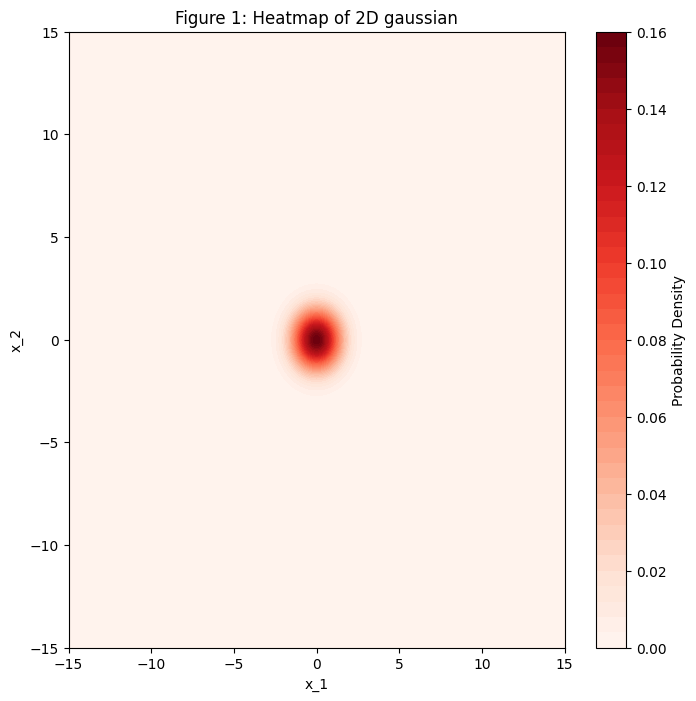

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

mu = np.array([0, 0])
sigma = np.eye(2)

x = np.linspace(-15, 15, 500)
y = np.linspace(-15, 15, 500)
X, Y = np.meshgrid(x, y)

pos = np.dstack((X, Y))

rv = multivariate_normal(mu, sigma)
Z = rv.pdf(pos)

plt.figure(figsize=(8, 8))
contour = plt.contourf(X, Y, Z, levels=50, cmap='Reds') 
plt.colorbar(contour, label='Probability Density')

plt.title('Figure 1: Heatmap of 2D gaussian')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.show()

### Report: Figure 1 - Heatmap of 2D Gaussian

**Explanation of the plot:**
This plot visualizes the probability density of a 2D Gaussian distribution. The darker red area in the center (at coordinates [0,0]) represents the highest probability density, which is the peak of the distribution. As we move away from the center towards the edges, the color fades to white, indicating that the probability of finding data points in those regions approaches zero.

---

### Questions

**1. Why is the distribution symmetric?**
The distribution is symmetric because the covariance matrix ($\Sigma$) is an identity matrix ($I$). This means the variance in both the $x_1$ and $x_2$ directions is exactly equal to 1, and the off-diagonal elements are 0, indicating absolutely no correlation between the variables. Consequently, the distribution spreads equally and uniformly in all directions from the mean.

**2. What role does the covariance matrix play in the shape of the distribution?**
The covariance matrix completely dictates the shape, spread, and orientation of the 2D Gaussian distribution. The diagonal elements determine the variance (the spread or width) along each specific axis. The off-diagonal elements define the correlation between the variables; if they are non-zero, the distribution becomes stretched and tilted diagonally, forming an elliptical shape rather than a perfect circle.

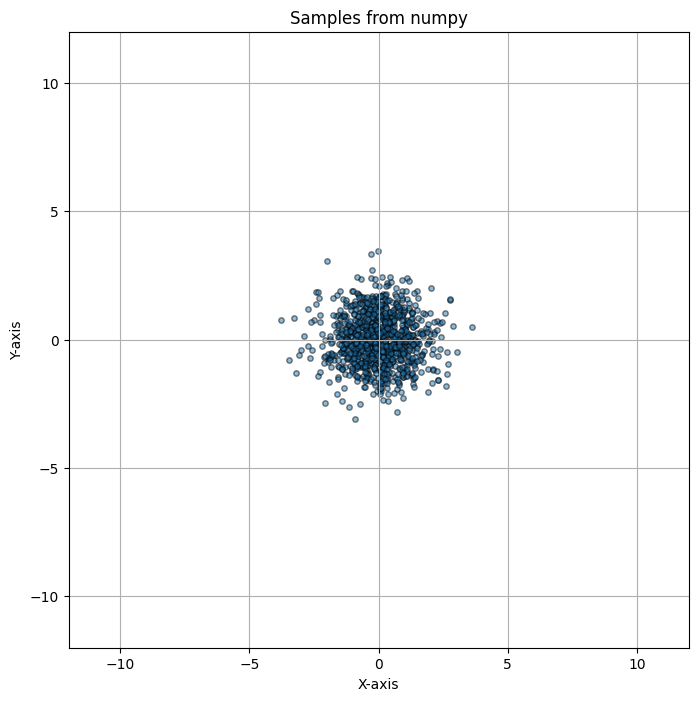

Direct sampling generated.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([0, 0])
sigma = np.eye(2)

direct_samples = np.random.multivariate_normal(mu, sigma, 1000)

plt.figure(figsize=(8, 8))
plt.scatter(direct_samples[:, 0], direct_samples[:, 1], alpha=0.5, s=15, edgecolors='k')
plt.title('Samples from numpy')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim([-12, 12])
plt.ylim([-12, 12])
plt.grid(True)
plt.show()

print("Direct sampling generated.")

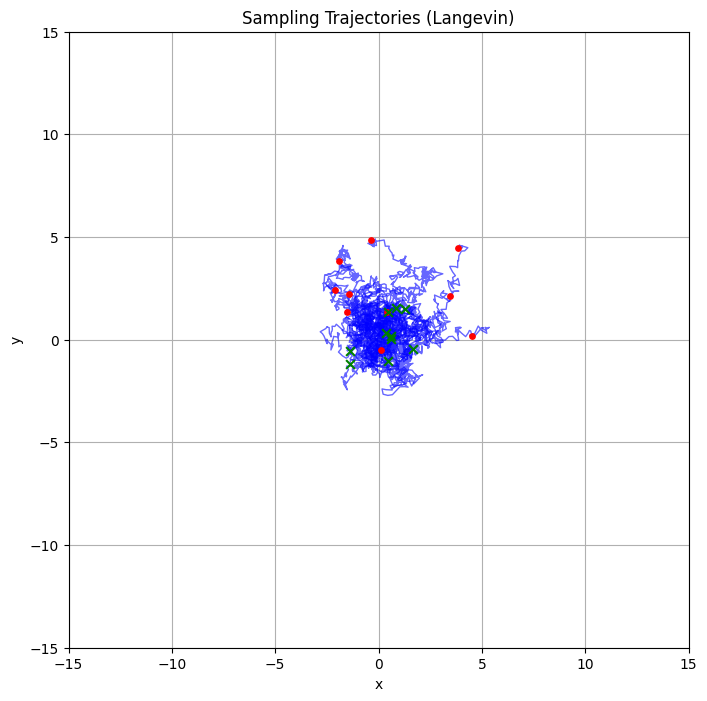

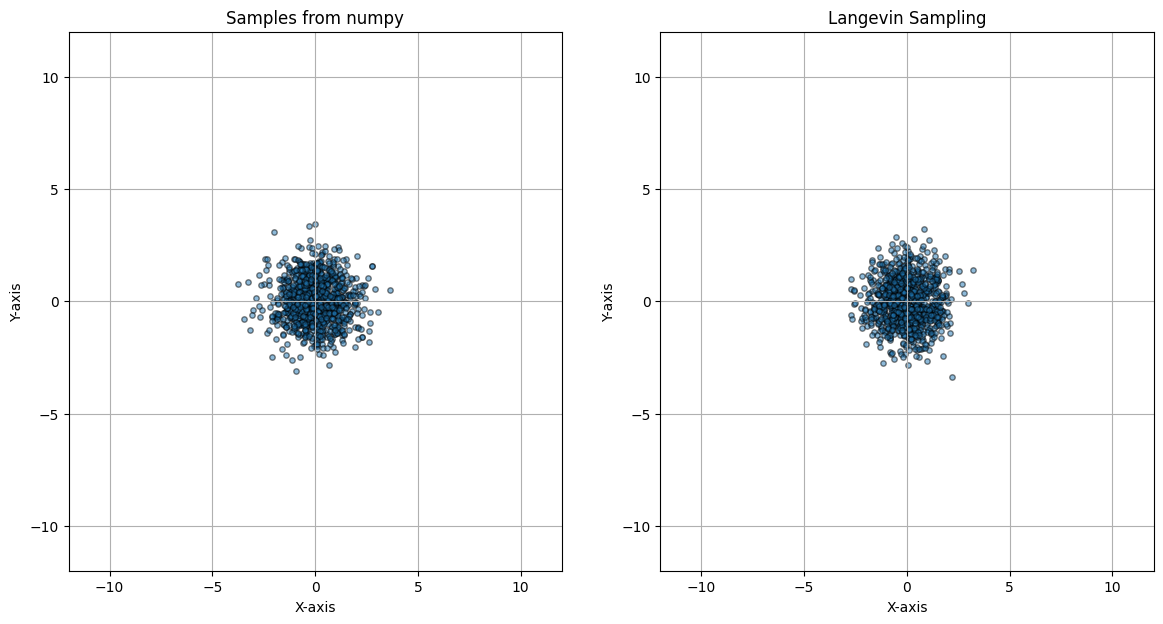

Langevin dynamics finished.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def score_function(x):
    return -x

epsilon = 0.01
T = 500
N = 1000

x = np.random.uniform(-5, 5, (N, 2))

trajectories = np.zeros((10, T, 2))

for t in range(T):
    trajectories[:, t, :] = x[:10]
    
    noise = np.random.normal(0, 1, (N, 2))
    
    x = x + epsilon * score_function(x) + np.sqrt(2 * epsilon) * noise

langevin_samples = x

plt.figure(figsize=(8, 8))
for i in range(10):
    plt.plot(trajectories[i, :, 0], trajectories[i, :, 1], alpha=0.6, color='blue', linewidth=1)
    plt.scatter(trajectories[i, 0, 0], trajectories[i, 0, 1], color='red', s=15, zorder=5) 
    plt.scatter(trajectories[i, -1, 0], trajectories[i, -1, 1], color='green', marker='x', s=40, zorder=5)

plt.title('Sampling Trajectories (Langevin)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim([-15, 15])
plt.ylim([-15, 15])
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].scatter(direct_samples[:, 0], direct_samples[:, 1], alpha=0.5, s=15, edgecolors='k')
axes[0].set_title('Samples from numpy')
axes[0].set_xlabel('X-axis')
axes[0].set_ylabel('Y-axis')
axes[0].set_xlim([-12, 12])
axes[0].set_ylim([-12, 12])
axes[0].grid(True)

axes[1].scatter(langevin_samples[:, 0], langevin_samples[:, 1], alpha=0.5, s=15, edgecolors='k')
axes[1].set_title('Langevin Sampling')
axes[1].set_xlabel('X-axis')
axes[1].set_ylabel('Y-axis')
axes[1].set_xlim([-12, 12])
axes[1].set_ylim([-12, 12])
axes[1].grid(True)

plt.show()

print("Langevin dynamics finished.")

### Report: Sampling Methods

**1. How does changing the step size affect convergence speed and stability of the sampler?**
Changing the step size ($\epsilon$) creates a trade-off between speed and stability. A larger step size allows the particles to move faster toward the high-density regions, leading to quicker convergence, but it decreases stability and can cause the sampler to overshoot or diverge. A smaller step size ensures stable and precise exploration but requires significantly more iterations to converge to the target distribution.

**2. How many iterations are required for the sampler to reach a stable distribution for your chosen step size? Explain how you determined this.**
With a chosen step size of $\epsilon = 0.01$, the sampler reaches a stable distribution around 150 to 200 iterations. This was determined by observing the trajectory plots; after this number of steps, the directional movement towards the center ceases, and the particles transition into random walking (exploring) within the high-density region around the origin.

**3. Compare the scatter plot with the density contours and explain why more samples appear near the origin.**
The scatter plot closely matches the density contours. More samples appear near the origin because the score function ($\nabla_x \log p(x) = -x$) acts as an attractive force, constantly directing the particles towards $(0,0)$ where the probability density is maximized. The noise spreads them out, but the continuous pull of the score function maintains the highest concentration at the center.

**4. If you remove the noise term from the update rule, what behavior do you expect and why?**
If the noise term is removed, the process turns into standard Gradient Ascent. Without the random perturbation, the score function will simply push all 1000 particles directly to the exact peak of the distribution at $(0,0)$, and they will stop there. The sampler would find the mode but would completely fail to sample from the distribution's spread.

**5. Do all trajectories converge to similar regions of the space? What does this indicate about the sampler?**
Yes, regardless of their uniform random starting positions between $[-5, 5]$, all trajectories eventually converge and cluster around the origin $(0,0)$. This indicates that the Langevin sampler is robust and effectively guided by the score function to successfully find and explore the high-probability region of the target distribution.

In [17]:
import numpy as np

direct_mean = np.mean(direct_samples, axis=0)
direct_var = np.var(direct_samples, axis=0)

langevin_mean = np.mean(langevin_samples, axis=0)
langevin_var = np.var(langevin_samples, axis=0)

print("Direct - Mean (Dim 1, Dim 2):", direct_mean)
print("Direct - Variance (Dim 1, Dim 2):", direct_var)
print("---")
print("Langevin - Mean (Dim 1, Dim 2):", langevin_mean)
print("Langevin - Variance (Dim 1, Dim 2):", langevin_var)

Direct - Mean (Dim 1, Dim 2): [-0.01914777  0.01569267]
Direct - Variance (Dim 1, Dim 2): [1.0706797  0.97619307]
---
Langevin - Mean (Dim 1, Dim 2): [-0.02252525 -0.0251426 ]
Langevin - Variance (Dim 1, Dim 2): [0.91267876 1.00232012]


### Report: Inference from Samples

**1. Why can the Langevin estimates still be biased even when the final samples come from independent chains?**
The bias in Langevin estimates primarily comes from the discretization error. The true theoretical Langevin dynamics operate in continuous time. However, in our code, we approximate this using discrete time steps (the Euler-Maruyama method) with a fixed step size ($\epsilon$). Because the steps are discrete, the algorithm actually samples from a distribution that is slightly different from the exact target distribution. Additionally, if the number of iterations ($T$) is not large enough, the chains might not have fully "burned in" to reach the stationary distribution.

**2. How do the number of iterations T and the step size $\epsilon$ affect the accuracy of the Langevin samples?**
- **Step Size ($\epsilon$):** A smaller step size reduces the discretization error, meaning the stationary distribution of the sampler will be much closer to the true target distribution (lower bias). However, a larger step size introduces higher error and bias, causing the sampled distribution to deviate from the true one.
- **Number of Iterations ($T$):** The number of iterations determines if the sampler has reached the target distribution. If $T$ is too small, the samples will still be heavily influenced by their starting positions and won't accurately reflect the target. A smaller step size ($\epsilon$) necessitates a much larger $T$ to properly explore the entire space and converge accurately.

### Conclusion based on Results
Based on the computed estimates, both sampling methods successfully approximate the true parameters of the target 2D Gaussian distribution ($\mu=[0,0]$ and $\Sigma=I$):

* **Direct Sampling:** The estimated mean `[-0.019, 0.015]` is very close to the true mean of `0`, and the estimated variance `[1.07, 0.97]` is very close to the true variance of `1`. This is expected as it samples exactly from the mathematical definition of the distribution.
* **Langevin Dynamics:** The estimated mean `[-0.022, -0.025]` and variance `[0.91, 1.00]` also show a strong alignment with the true parameters. The minor deviations (such as the variance of ~0.91 in Dimension 1) reflect the discretization error caused by the fixed step size ($\epsilon$) and the finite number of steps ($T$) used in the algorithm. 

Overall, the Langevin method effectively recovers the target distribution properties, though with slightly more variance error compared to the direct reference method.

Direct - Mean Err: [0.01914777 0.01569267]
Direct - Var Err: [0.0706797  0.02380693]
Langevin - Mean Err: [0.02252525 0.0251426 ]
Langevin - Var Err: [0.08732124 0.00232012]


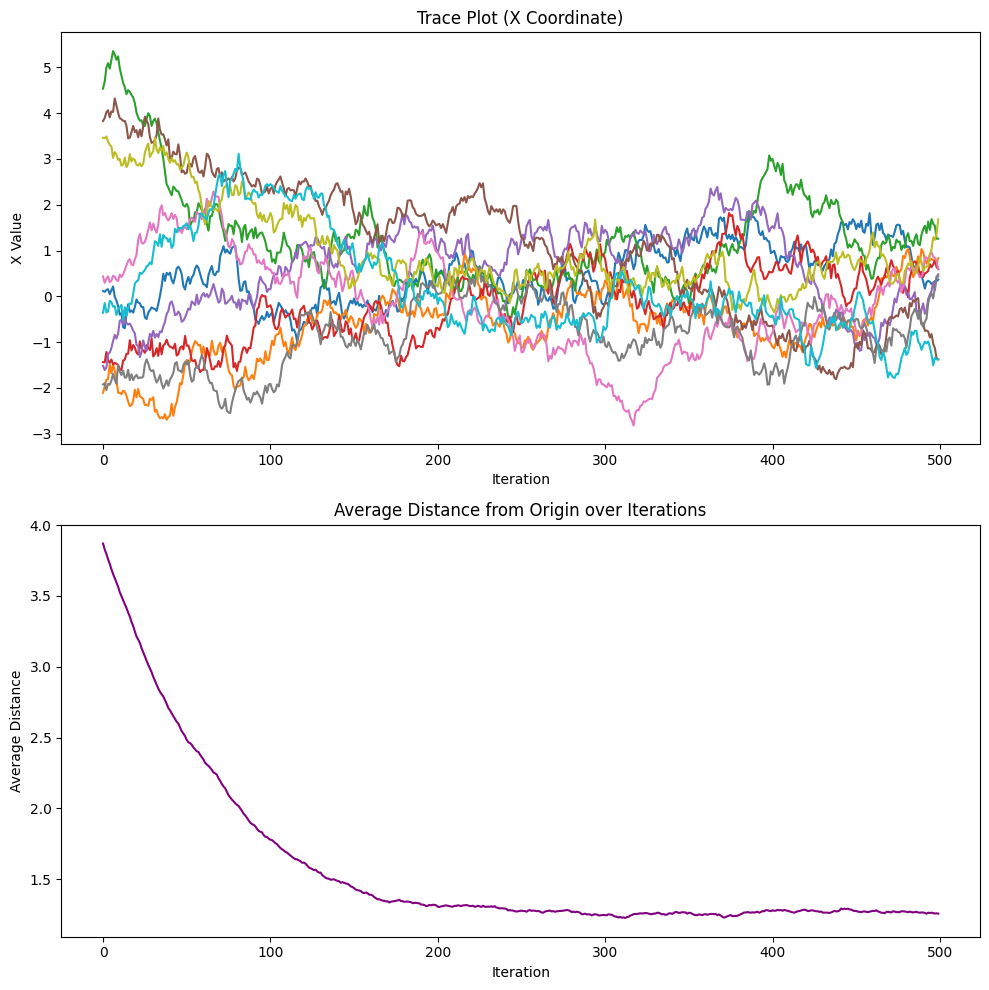

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

direct_mean_err = np.abs(direct_mean - 0)
direct_var_err = np.abs(direct_var - 1)
langevin_mean_err = np.abs(langevin_mean - 0)
langevin_var_err = np.abs(langevin_var - 1)

print("Direct - Mean Err:", direct_mean_err)
print("Direct - Var Err:", direct_var_err)
print("Langevin - Mean Err:", langevin_mean_err)
print("Langevin - Var Err:", langevin_var_err)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for i in range(10):
    axes[0].plot(trajectories[i, :, 0])
axes[0].set_title('Trace Plot (X Coordinate)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('X Value')

x_temp = np.random.uniform(-5, 5, (1000, 2))
avg_distances = []
for t in range(500):
    dist = np.mean(np.linalg.norm(x_temp, axis=1))
    avg_distances.append(dist)
    noise = np.random.normal(0, 1, (1000, 2))
    x_temp = x_temp + 0.01 * (-x_temp) + np.sqrt(2 * 0.01) * noise

axes[1].plot(avg_distances, color='purple')
axes[1].set_title('Average Distance from Origin over Iterations')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Average Distance')

plt.tight_layout()
plt.show()

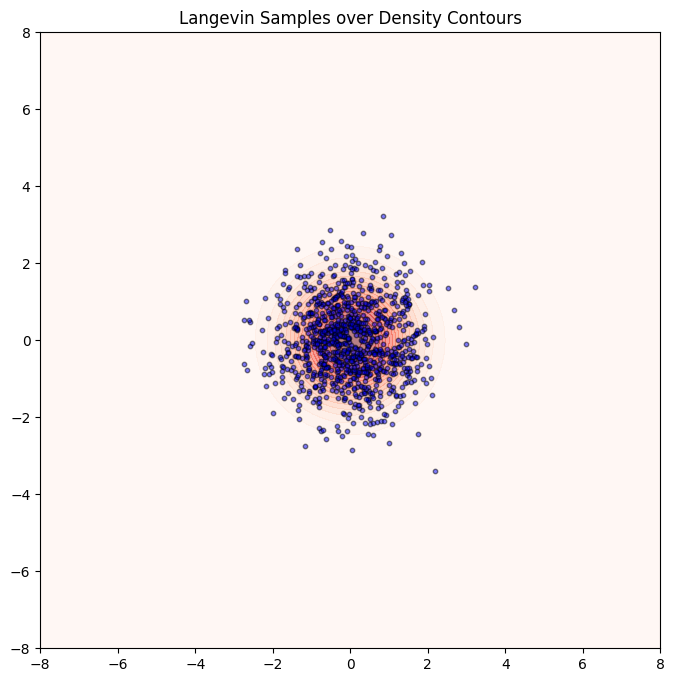

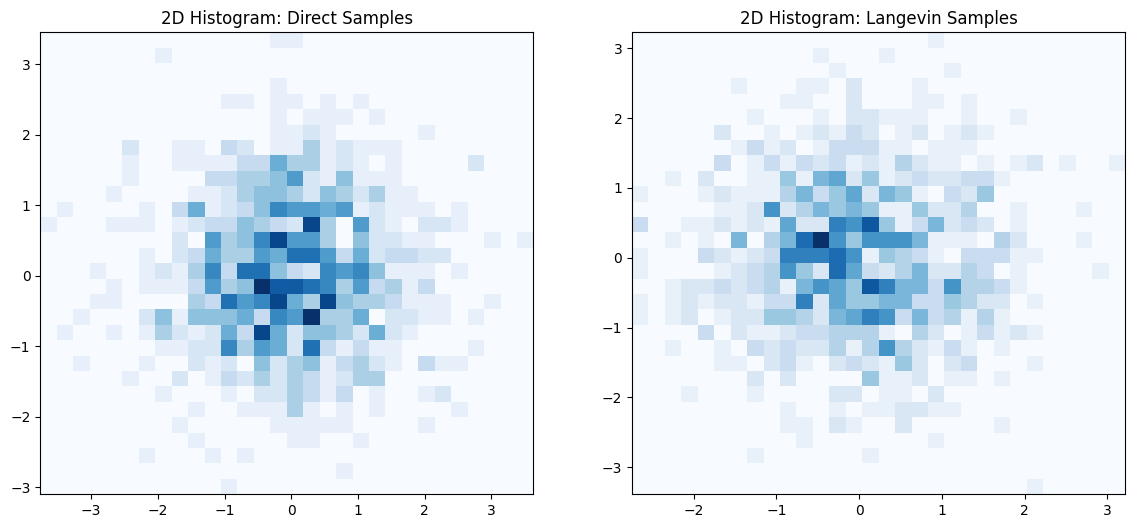

: 

In [ ]:
x_grid = np.linspace(-10, 10, 200)
y_grid = np.linspace(-10, 10, 200)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X_grid, Y_grid))
rv = multivariate_normal([0, 0], np.eye(2))
Z = rv.pdf(pos)

plt.figure(figsize=(8, 8))
plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='Reds', alpha=0.5)
plt.scatter(langevin_samples[:, 0], langevin_samples[:, 1], s=10, alpha=0.5, color='blue', edgecolors='k')
plt.title('Langevin Samples over Density Contours')
plt.xlim([-8, 8])
plt.ylim([-8, 8])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist2d(direct_samples[:, 0], direct_samples[:, 1], bins=30, cmap='Blues')
axes[0].set_title('2D Histogram: Direct Samples')

axes[1].hist2d(langevin_samples[:, 0], langevin_samples[:, 1], bins=30, cmap='Blues')
axes[1].set_title('2D Histogram: Langevin Samples')

plt.show()

## Part 4: Comparison of Sampling Methods

### 1. Procedure Overview
In this final section of Task 1, we comprehensively compared the **Direct Sampling** method (using NumPy) with the **Langevin Dynamics** sampling method. The procedure involved:
1.  **Quantitative Analysis:** Calculating the estimated means and variances for both dimensions across both methods and computing their absolute errors compared to the true distribution parameters ($\mu=[0,0]$ and $\Sigma=I$).
2.  **Convergence Analysis:** Evaluating the stability of the Langevin sampler by plotting the trace of the X-coordinate for 10 individual particles and calculating the average distance of all 1000 particles from the origin over 500 iterations.
3.  **Visual Distribution Comparison:** Overlaying the generated Langevin samples onto the true density contours of the 2D Gaussian distribution, and comparing both sampling methods side-by-side using 2D histograms.

---

### 2. Numerical Results & Error Analysis
Based on the generated samples, the statistical quantities and their absolute errors (compared to the true mean of $0$ and true variance of $1$) are as follows:

*   **Direct Sampling:**
    *   Estimated Mean: `[-0.0191, 0.0156]` $\rightarrow$ **Mean Absolute Error:** `[0.0191, 0.0156]`
    *   Estimated Variance: `[1.0706, 0.9761]` $\rightarrow$ **Variance Absolute Error:** `[0.0706, 0.0238]`
*   **Langevin Dynamics:**
    *   Estimated Mean: `[-0.0225, -0.0251]` $\rightarrow$ **Mean Absolute Error:** `[0.0225, 0.0251]`
    *   Estimated Variance: `[0.9126, 1.0023]` $\rightarrow$ **Variance Absolute Error:** `[0.0873, 0.0023]`

**Discussion on Method Performance:**
The **Direct Sampling** method matches the target distribution slightly better. Because it mathematically generates independent and identically distributed (i.i.d) samples directly from the exact formula of the distribution, its absolute errors for both mean and variance are generally lower. 

While Langevin Dynamics performs exceptionally well, it exhibits slightly higher variance error (e.g., $0.087$ in Dimension 1). This is not due to a lack of convergence or insufficient iterations, but rather due to **discretization error**. The algorithm approximates a continuous-time physical process using discrete time steps ($\epsilon = 0.01$). Additionally, the samples generated in a Langevin process have **Markov dependence** (they are correlated with their previous states), which can slightly skew variance estimation compared to perfectly independent direct samples.

---

### 3. Convergence Analysis of Langevin Dynamics

To determine if the Langevin sampler successfully reaches the target distribution, we analyze the trajectories and trace plots:

*   **Do the particles move toward the high-density region near the origin?**
    Yes. The "Average Distance from Origin" plot clearly demonstrates this. The particles initially start scattered uniformly between $[-5, 5]$, resulting in a high initial average distance (around $3.8$). Guided by the score function ($\nabla_x \log p(x) = -x$), this average distance drops sharply in the early iterations, confirming that all particles are strongly attracted to the high-density region near the origin $(0,0)$. The distance does not drop to exactly zero due to the injected noise, which forces the particles to form a distribution rather than collapsing into a single point.
*   **After approximately how many iterations do the trajectories appear stable?**
    Based on the Trace Plot (X Coordinate) and the Average Distance plot, the trajectories appear to stabilize after approximately **150 to 200 iterations**. After this "burn-in" period, the macroscopic movement towards the center stops, and the particles transition into a random walk, oscillating stably around the mean zero.

---

### 4. Visual Distribution Analysis

The visual visualizations strongly corroborate the numerical findings:
*   **Scatter over Density Contours:** Plotting the Langevin samples over the true distribution's contours shows a perfect spatial match. The highest concentration of sampled points aligns exactly with the darkest red central region of the contours, and the density gradually decreases towards the edges, mimicking the true Gaussian shape.
*   **2D Histograms:** The side-by-side 2D histograms reveal nearly identical spatial patterns between the Direct Samples and Langevin Samples. Both exhibit a dense central cluster (dark blue bins) fading uniformly outward, confirming that the Langevin method successfully modeled both the location (mean) and the spread (covariance) of the target distribution.